# Module 4 Restoration Monitoring
**Region:** Cache la Poudre watershed/2020 Cameron Peak Fire burn scar

`wildfire-landscape-intelligence` Module 3 tracks passive post-fire recovery.
This module tracks recovery against *interventions* such as mulching, seeding,
check-dam placement, which is a harder question, because treated ground would
have recovered somewhat regardless.

The whole design follows from that. Treated areas almost always improve after
treatment, since treatment happens after disturbance and disturbance is followed
by recovery whether or not anyone shows up. So a before/after comparison of
treated areas alone will show an effect essentially every time, and that effect
means nothing. Paired difference-in-differences against comparable untreated
ground is what separates the intervention from the recovery it rode in on.

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import time
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import box
import daear_toolkit as dt
from daear_toolkit import data_access, indicators, viz, hydrology

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox
FIRE_YEAR = REGION.fire_year   # 2020

terrain = data_access.get_terrain(BBOX)
burn = data_access.get_burn_severity(BBOX, fire_year=FIRE_YEAR)
soil = data_access.get_soil_properties(BBOX)

## The treatment layer

This is the one input the toolkit cannot fetch. Treatment footprints live with
whoever did the work. For this AOI, the Coalition for the Poudre River
Watershed, the Big Thompson Watershed Coalition, USFS ARP post-fire BAER
records, and Larimer County. They are not a public API; they arrive as
shapefiles, and sometimes as PDFs of shapefiles.

Two consequences worth being upfront about:

- Getting this layer is a relationship task, not a data-engineering task. Budget
  for it accordingly.
- Treatment records vary in positional accuracy. A polygon drawn to describe a
  work order is not the same as a polygon surveyed from the treated boundary,
  and at 30 m resolution that difference contaminates edge pixels. Buffering the
  boundary inward before analysis is the standard defence.

In [2]:
# Create a synthetic shapefile for demonstration purposes


# Placeholder treatment polygons within the Poudre/Cameron Peak area
# Replace with real BAER or post-fire treatment data when available
treatments = gpd.GeoDataFrame({
    "treatment_type": ["seeding", "mulching", "erosion_barrier", "seeding"],
    "treatment_year": [2021, 2021, 2021, 2022],
    "area_ha":        [45.2, 12.8, 3.1, 67.4],
    "geometry": [
        box(-105.72, 40.58, -105.68, 40.62),
        box(-105.65, 40.55, -105.62, 40.58),
        box(-105.70, 40.52, -105.68, 40.55),
        box(-105.60, 40.60, -105.56, 40.64),
    ]
}, crs="EPSG:4326")

print(f"{len(treatments)} treatment polygons (placeholder)")
print(treatments["treatment_type"].value_counts())

data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

treatments.to_file(data_dir / "poudre_post_fire_treatments.geojson", driver="GeoJSON")
print("Saved: ../data/poudre_post_fire_treatments.geojson")

4 treatment polygons (placeholder)
treatment_type
seeding            2
mulching           1
erosion_barrier    1
Name: count, dtype: int64
Saved: ../data/poudre_post_fire_treatments.geojson


In [3]:
TREATMENT_PATH = "../data/poudre_post_fire_treatments.geojson"

treatments = gpd.read_file(TREATMENT_PATH).to_crs("EPSG:4326")
print(f"{len(treatments)} treatment polygons")
print(treatments["treatment_type"].value_counts())

# Inward buffer to drop mixed edge pixels: at 30 m, a one-pixel boundary error
# puts untreated ground in the treated sample and biases the estimate toward zero.
treatments_core = treatments.copy()
treatments_core["geometry"] = treatments.to_crs(epsg=5070).buffer(-45).to_crs("EPSG:4326")
treatments_core = treatments_core[~treatments_core.is_empty]

treated_id, treated_lookup = data_access.rasterize_watersheds(treatments_core, template=burn, id_column="treatment_type")
treated = treated_id.notnull()
print(f"Treated area after inward buffer: {float(treated.mean()):.1%} of AOI")

4 treatment polygons
treatment_type
seeding            2
mulching           1
erosion_barrier    1
Name: count, dtype: int64
Treated area after inward buffer: 3.2% of AOI


## Build a comparable control

`~treated` is not a control. Untreated ground in this AOI includes unburned
forest, wilderness where treatment was never permitted, and low-severity ground
nobody needed to treat. Comparing treated areas against that mixture measures
the siting decision, not the treatment.

Crews treat the worst ground first, so treated areas are systematically steeper,
more severely burned, and more connected than the landscape average. A defensible
control has to match on those three axes: burn severity, slope, and connectivity
class and be drawn only from ground that was eligible for treatment.

In [4]:
# Stratify on the variables that drove siting.
sev_class = xr.apply_ufunc(np.digitize, burn, kwargs={"bins": [0.25, 0.5, 0.75]})
slope_class = xr.apply_ufunc(np.digitize, terrain["slope_deg"], kwargs={"bins": [10, 20, 30]})
strata = sev_class * 10 + slope_class

# Candidate controls: burned, untreated, and inside a stratum that actually
# contains treated cells. The last condition is what enforces comparability 
# a stratum with no treated cells has no counterfactual to offer.
treated_strata = set(np.unique(strata.where(treated).values[np.isfinite(strata.where(treated).values)]))
eligible = (burn > 0.25) & (~treated) & strata.isin(list(treated_strata))

print(f"Treated cells:            {int(treated.sum())}")
print(f"Matched control cells:    {int(eligible.sum())}")
print(f"Naive control (~treated): {int((~treated).sum())}  <- would have been the wrong comparison")

balance = pd.DataFrame({
    "treated": [float(burn.where(treated).mean()), float(terrain["slope_deg"].where(treated).mean())],
    "matched_control": [float(burn.where(eligible).mean()), float(terrain["slope_deg"].where(eligible).mean())],
    "naive_control": [float(burn.where(~treated).mean()), float(terrain["slope_deg"].where(~treated).mean())],
}, index=["mean_burn_severity", "mean_slope_deg"]).round(2)
print("\nCovariate balance:")
balance

Treated cells:            970
Matched control cells:    10790
Naive control (~treated): 29230  <- would have been the wrong comparison

Covariate balance:


,treated,matched_control,naive_control
mean_burn_severity,0.35,0.36,0.22
mean_slope_deg,12.71,13.92,13.75


## Check parallel trends before estimating anything

Difference-in-differences identifies a causal effect only if treated and control
areas *would have* followed the same trajectory absent treatment. That
assumption is untestable in the post-period by construction, but it is testable
in the pre-period, and if the two groups were already diverging before treatment,
the estimate below is measuring that divergence.

Run the check first. If it fails, report the failure rather than the effect.

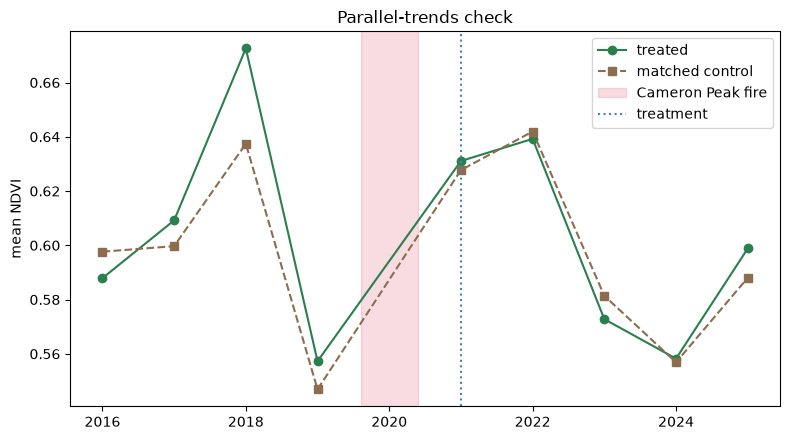

Pre-fire drift in the treated-control gap: +0.0086 NDVI/yr
Interpretation: near zero supports parallel trends; a clear slope means the DiD estimate below is partly measuring pre-existing divergence and should be reported as such.


In [5]:
def annual_ndvi(year, month_day="08-15"):
    """One consistent late-summer date per year so phenology is not read as trend."""
    scene = data_access.get_optical_scene(
        BBOX,
        date=f"{year}-{month_day}",
        source="sentinel-2",
    )
    return indicators.ndvi(scene).assign_coords(time=pd.Timestamp(f"{year}-{month_day}"))

PRE_YEARS = [2016, 2017, 2018, 2019]           # before the fire
POST_YEARS = [2021, 2022, 2023, 2024, 2025]    # after fire and treatment
TREATMENT_YEAR = 2021

series = xr.concat([annual_ndvi(y) for y in PRE_YEARS + POST_YEARS], dim="time")

means = pd.DataFrame({
    "year": PRE_YEARS + POST_YEARS,
    "treated": [float(series.sel(time=f"{y}-08-15", method="nearest").where(treated).mean())
                for y in PRE_YEARS + POST_YEARS],
    "control": [float(series.sel(time=f"{y}-08-15", method="nearest").where(eligible).mean())
                for y in PRE_YEARS + POST_YEARS],
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(means["year"], means["treated"], "o-", label="treated", color="#2a7f4f")
ax.plot(means["year"], means["control"], "s--", label="matched control", color="#8c6d4f")
ax.axvspan(FIRE_YEAR - 0.4, FIRE_YEAR + 0.4, color="crimson", alpha=0.15, label="Cameron Peak fire")
ax.axvline(TREATMENT_YEAR, color="steelblue", ls=":", label="treatment")
ax.set_ylabel("mean NDVI"); ax.legend(); ax.set_title("Parallel-trends check")
plt.tight_layout()
plt.savefig("../outputs/04_parallel_trends.png", dpi=150)
plt.show()

pre = means[means["year"] < FIRE_YEAR]
gap_drift = np.polyfit(pre["year"], pre["treated"] - pre["control"], 1)[0]
print(f"Pre-fire drift in the treated-control gap: {gap_drift:+.4f} NDVI/yr")
print("Interpretation: near zero supports parallel trends; a clear slope means the DiD "
      "estimate below is partly measuring pre-existing divergence and should be reported as such.")

## The difference-in-differences estimate

In [6]:
pre_ndvi  = series.sel(time=slice("2016", "2019")).mean(dim="time")
post_ndvi = series.sel(time="2024-08-15", method="nearest")

did = indicators.difference_in_differences(pre_ndvi, post_ndvi, treated_mask=treated, control_mask=eligible)
for k, v in did.items():
    for k, v in did.items():
        print(f"{k:22s} {v:.4f}" if isinstance(v, float) else f"{k:22s} {v}")

print(f"\nTreated areas recovered {did['did_estimate']:+.4f} NDVI more than matched untreated areas,")
print("relative to their own pre-fire baselines.")

# By treatment type for an operationally useful cut, since it informs what to fund next.
by_type = []
for code, ttype in treated_lookup.items():
    mask = treated_id == code
    if float(mask.sum()) < 50:
        continue
    r = indicators.difference_in_differences(pre_ndvi, post_ndvi, treated_mask=mask, control_mask=eligible)
    by_type.append({"treatment": ttype, "n_cells": r["n_treated_cells"], "did_estimate": r["did_estimate"]})

by_type = pd.DataFrame(by_type).sort_values("did_estimate", ascending=False).round(4)
by_type.to_csv("../outputs/04_did_by_treatment_type.csv", index=False)
by_type

treated_pre            0.6067
treated_post           0.5582
treated_change         -0.0485
control_pre            0.5954
control_post           0.5569
control_change         -0.0385
did_estimate           -0.0100
n_treated_cells        970
n_control_cells        10790
treated_pre            0.6067
treated_post           0.5582
treated_change         -0.0485
control_pre            0.5954
control_post           0.5569
control_change         -0.0385
did_estimate           -0.0100
n_treated_cells        970
n_control_cells        10790
treated_pre            0.6067
treated_post           0.5582
treated_change         -0.0485
control_pre            0.5954
control_post           0.5569
control_change         -0.0385
did_estimate           -0.0100
n_treated_cells        970
n_control_cells        10790
treated_pre            0.6067
treated_post           0.5582
treated_change         -0.0485
control_pre            0.5954
control_post           0.5569
control_change         -0.0385
did_estimat

,treatment,n_cells,did_estimate
0,seeding,380,0.0106
2,seeding,380,-0.0026
1,mulching,210,-0.0605


## Soil moisture recovery

`data_access.get_soil_moisture` wires SMAP L3 enhanced (9 km) into the toolkit.

The resolution caveat determines what this layer can be used for. A single 9 km 
SMAP pixel spans both treated and untreated ground in essentially every treatment 
layout in this AOI, so it cannot support the paired contrast above. It gives 
basin-scale hydrologic context: is the whole watershed wetting up or drying out, 
and does the vegetation signal make sense against that backdrop? Use it that way and say so.

In [ ]:
sm = data_access.get_soil_moisture(BBOX, start="2016-01-01", end="2025-12-31", product="SPL3SMP_E")
print(f"{sm.sizes['time']} SMAP granules, grid {sm.isel(time=0).shape} at ~9 km")

# Late-summer means, matching the NDVI compositing window so the two are comparable.
sm_annual = sm.sel(time=sm["time"].dt.month.isin([8, 9])).groupby("time.year").mean()

fig, ax = plt.subplots(figsize=(8, 4))
sm_annual.mean(dim=["y", "x"]).plot(ax=ax, marker="o", color="#3b6ea5")
ax.axvspan(FIRE_YEAR - 0.4, FIRE_YEAR + 0.4, color="crimson", alpha=0.15)
ax.set_ylabel("volumetric soil moisture (cm3/cm3)"); ax.set_title("Basin-mean late-summer soil moisture")
plt.tight_layout()
plt.savefig("../outputs/04_soil_moisture_trend.png", dpi=150)
plt.show()

sm_recovery = indicators.recovery_ratio(
    sm_annual.sel(year=2024),
    sm_annual.sel(year=slice(2016, 2019)).mean(dim="year"),
)
print(f"Basin-mean soil moisture recovery ratio (2024 vs. 2016-2019): {float(sm_recovery.mean()):.2f}")

c:\Users\gekek\miniconda3\envs\daear\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\gekek\miniconda3\envs\daear\Lib\site-packages\earthaccess\results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
c:\Users\gekek\miniconda3\envs\daear\Lib\site-packages\earthaccess\store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 3571/3571 [00:00<00:00, 16223.22it/s]
PROCESSING TASKS | :   8%|▊         | 302/3571 [2:51:50<31:00:06, 34.14s/it]


## Landscape function over time

The roll-up: vegetation recovery, soil moisture recovery, and the Module 3
watershed-resilience index combined into one index, tracked year by year for
treated and control areas separately.

Weights default to 0.4 / 0.2 / 0.4 — soil moisture is downweighted for the
resolution reason above. It contributes context, so it should not drive the
composite.

In [ ]:
# Compute static inputs once outside the loop
soil_vuln_base = indicators.soil_vulnerability(
    soil["organic_matter_pct"], soil["sand_fraction_pct"], terrain["slope_deg"]
)
erosion_base = indicators.erosion_susceptibility(
    terrain["slope_deg"], burn, soil["runoff_potential"]
)

print("Computing series... (this may take a minute)")
t0 = time.time()
series = series.compute()   # force xarray lazy → in-memory
print(f"Series computed in {time.time()-t0:.1f}s, shape: {series.shape}")

rows = []
for year in POST_YEARS:
    ndvi_y = series.sel(time=f"{year}-08-15", method="nearest")
    veg_recovery = indicators.recovery_ratio(ndvi_y, pre_ndvi)

    # Update soil vulnerability with vegetation recovery for this year
    soil_vuln_y = (soil_vuln_base
                   + 0.5 * burn * (1 - veg_recovery.clip(0, 1))).clip(0, 1)

    resilience_y = indicators.watershed_resilience_index(erosion_base, soil_vuln_y)
    lfi = indicators.landscape_function_index(veg_recovery, None, resilience_y)

    rows.append({
        "year": year,
        "treated": float(lfi.where(treated).mean()),
        "control": float(lfi.where(eligible).mean()),
    })
    print(f"  {year} done")   # progress indicator

lfi_series = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lfi_series["year"], lfi_series["treated"], "o-", label="treated", color="#2a7f4f")
ax.plot(lfi_series["year"], lfi_series["control"], "s--", label="matched control", color="#8c6d4f")
ax.set_ylabel("landscape function index")
ax.legend()
ax.set_title("Landscape function, treated vs. matched control")
plt.tight_layout()
plt.savefig("../outputs/04_landscape_function.png", dpi=150)
plt.show()

lfi_series.to_csv("../outputs/04_landscape_function_series.csv", index=False)
lfi_series.round(3)

## Summary

Restoration effect estimated the way it has to be estimated: matched controls,
a parallel-trends check run before the estimate rather than after, and results
broken out by treatment type so they inform the next funding decision.

Module 1 establishes soil condition, Module 2 routes water through it, 
Module 3 chains fire through soil to watershed resilience, and Module 4 
asks whether intervention changed the trajectory each one reusing the 
same toolkit rather than re-deriving a pipeline.

**Constraints a reader should hold onto:**

- DiD is causal only under parallel trends. Step 3 tests that assumption; if it
  fails, the number in Step 4 is descriptive and must be labelled as such.
- Treatment polygon accuracy is the dominant uncertainty, ahead of anything in
  the remote sensing. The inward buffer helps and does not fix it.
- SMAP at 9 km cannot resolve treatment-scale contrast. It is context.
- NDVI recovery is not ecological recovery. A treated slope flushing with
  cheatgrass scores well here, and that is a real failure mode of the metric 
  species composition needs field data, which is the argument for pairing this
  with monitoring plots rather than replacing them.